<a href="https://colab.research.google.com/github/genairsh/GenAI_Level3_Assignment/blob/main/bronze/Problem2_loanDefault.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Step 1 : Load Dataset
dataset = pd.read_csv("https://raw.githubusercontent.com/genairsh/GenAI_Level3_Assignment/main/datasets/loan_default.csv")


In [4]:
print(dataset.columns)

Index(['Age', 'AnnualIncome(lakhs)', 'CreditScore(300-900)',
       ' LoanAmount(lakhs)', ' LoanTerm(years)', ' EmploymentType',
       ' loan(yes/no) '],
      dtype='object')


In [6]:
print(dataset)

   Age  AnnualIncome(lakhs)  CreditScore(300-900)   LoanAmount(lakhs)  \
0   28                  6.5                   720                   5   
1   45                 12.0                   680                  10   
2   35                  8.0                   750                   6   
3   50                 15.0                   640                  12   
4   30                  7.0                   710                   5   
5   42                 10.0                   660                   9   
6   26                  5.5                   730                   4   
7   48                 14.0                   650                  11   
8   38                  9.0                   700                   7   
9   55                 16.0                   620                  13   

    LoanTerm(years)  EmploymentType   loan(yes/no)   
0                 5        Salaried               0  
1                10   Self-Employed               1  
2                 7        Salarie

In [7]:
dataset.columns = dataset.columns.str.strip()

In [8]:
#Step 2 : Convert EmploymentType into Numbers
# Salaried -> 0
# Self-Employed -> 1
# LabelEncoder assigns numbers alphabetically
label = LabelEncoder()
dataset["EmploymentType"] = label.fit_transform(dataset["EmploymentType"])

In [9]:
print(label.classes_)

['Salaried' 'Self-Employed']


In [10]:
##Step 3: Extract input fetaures and output
inputx = dataset.iloc[:,:-1]
outputy = dataset.iloc[:,-1]

In [19]:
###Step 4: Split input data, 75% training data,25% test data
input_train, input_test, output_train, output_test = train_test_split(inputx, outputy, test_size=0.2, random_state=42)

In [20]:
# Step 5 : Feature Scaling
# If one feature (like Credit Score) has much larger values than
#the others, it dominates the distance calculation in KNN.To prevent
#this, scale all features to a similar range.
scaler = StandardScaler()

##fit:The scaler looks at the training data and calculates the mean(average)
###and standard deviation(stdDeviation) of each feature
###transform:Then it converts every value to (value-mean)/stdDeviation
input_train = scaler.fit_transform(input_train)

#The test data must be scaled using the same mean and stdDeviation learned from
#the training data.so only transform
input_test = scaler.transform(input_test)

In [21]:
###Train Model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(input_train, output_train)

print("Model Used:", model)

Model Used: KNeighborsClassifier(n_neighbors=3)


In [22]:
#Predict output for test data
predicted_output = model.predict(input_test)

In [23]:
#Evaluation of Model
##
print("\nAccuracy:", accuracy_score(output_test, predicted_output))
print("\nConfusion Matrix")
print(confusion_matrix(output_test, predicted_output))
print("\nClassification Report")
print(classification_report(output_test, predicted_output))



Accuracy: 1.0

Confusion Matrix
[[1 0]
 [0 1]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [24]:
#Test using one training record
sample = input_train[0].reshape(1, -1)

prediction = model.predict(sample)

print("\nPrediction using one training sample ",sample)
print("Actual :", output_train[0])
print("Predicted :", prediction[0])


Prediction using one training sample  [[ 0.26624161 -0.06401844 -0.55555556  0.26252051  0.20704985 -0.77459667]]
Actual : 0
Predicted : 0


In [25]:
#Predict New Customer
# Age, Income, Credit Score,
# Loan Amount, Loan Term,
# EmploymentType

new_customer = [[40,11,690,8,10,0]]
new_customer = scaler.transform(new_customer)
result = model.predict(new_customer)

if result[0] == 1:
    print("\nLoan Default : YES")
else:
    print("\nLoan Default : NO")


Loan Default : NO


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


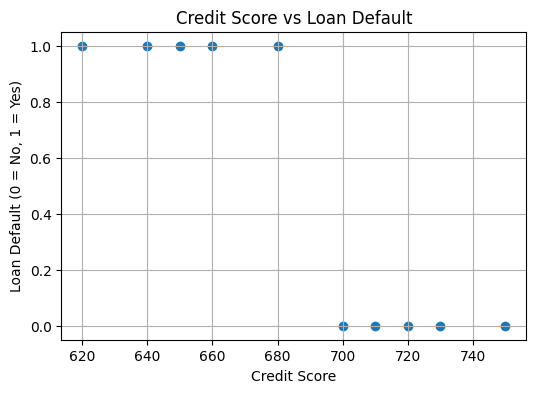

In [28]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(6,4))

plt.scatter(dataset["CreditScore(300-900)"],
            dataset["loan(yes/no)"],
            marker='o')

plt.xlabel("Credit Score")
plt.ylabel("Loan Default (0 = No, 1 = Yes)")
plt.title("Credit Score vs Loan Default")

plt.grid(True)
plt.show()

In [29]:
####Using DescionTree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(input_train, output_train)

# Predict
dt_pred = dt_model.predict(input_test)

# Accuracy
print("Decision Tree Accuracy:",
      accuracy_score(output_test, dt_pred))

Decision Tree Accuracy: 1.0


**Interpretation**
**1. Identify high-risk customers.** High-risk customers are those predicted as Loan Default = 1.

Typical characteristics include:
  Low credit score,
  High loan amount,
  Long loan term,
  Lower annual income,
  Self-employed (in this dataset several defaulting customers are self-employed)

These customers should receive additional financial assessment before loan approval.

**2. What patterns lead to loan default?**
The dataset suggests that customers are more likely to default when they have:

Lower credit scores
Higher loan amounts
Longer loan repayment periods
Lower income relative to the requested loan amount

These factors increase the financial risk of default.

**3.How do credit score and income influence predictions?**
Both features are important.

A higher credit score indicates better repayment history, reducing the likelihood of default.
A higher annual income improves the customer's repayment capacity, making default less likely.

Customers with low income and low credit scores are generally predicted as higher risk.

**4. Suggest banking policies based on model output.**
The bank can use the model to:

Approve loans quickly for low-risk customers.
Conduct additional verification for high-risk applicants.
Offer lower loan amounts or shorter repayment periods to risky customers.
Require collateral or guarantors for applicants predicted to default.
Recommend financial counseling for customers with poor credit history.

**5. Compare KNN with Decision Trees for this problem.**
KNN	Decision Tree

Predicts using nearby customers

Learns decision rules from training data
Requires feature scaling	Usually does not require feature scaling
Simple to understand	Easy to interpret with decision rules
Prediction can be slower for large datasets	Faster predictions after training
Sensitive to the value of k	Can overfit if not pruned


**6. What happens if LoanAmount dominates distance calculation?**
KNN uses distance to find similar customers.
If LoanAmount has much larger values than the other features and the data is not scaled:
  LoanAmount will dominate the distance calculation.
  Other important features like Credit Score and Income will have much less influence.
  Predictions may become inaccurate.

Using StandardScaler prevents this problem by putting all features on a similar scale.

**7. Should KNN be used in real-time loan approval systems?**
KNN can be used for small datasets, but it is generally not the best choice for large real-time loan approval systems.

Reasons:
KNN must compare a new customer with many existing customers, making predictions slower as the dataset grows.
It also requires storing all training data.

For large banking applications, models such as Decision Trees, Random Forests, or Gradient Boosting are usually preferred because they provide faster predictions and are easier to interpret.